# TP1 — Visión por Computadora I

**Tema:** Operadores de píxel, corrección de color (White Patch) e histogramas (Clase 2)

**Alumno:** Romero Federico, Ailen Muñoz

---

### Cómo leer este notebook

- Las cajas con **fondo y borde verde** : contienen las conclusiones del equipo.
- El resto de las celdas estan agrupadas por punto y contienen el código relativo a ese punto.


## Setup

Importamos las librerías necesarias y definimos las rutas a las imágenes provistas en `Material_TPs/TP1`.

In [1]:
import os
import glob

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

# Rutas relativas: este notebook vive en vision_por_computadora/TP1/, junto al material del TP
BASE_DIR = "."
WP_DIR = os.path.join(BASE_DIR, "white_patch")

assert os.path.isdir(BASE_DIR), f"No se encontró {BASE_DIR}. Revisar desde dónde se corre el notebook."
os.listdir(WP_DIR)

['wp_green2.jpg',
 'wp_red2.jpg',
 'test_green.png',
 'wp_red.png',
 'wp_green.png',
 'wp_blue.jpg',
 'test_red.png',
 'test_blue.png']

## Parte 1 — Algoritmo White Patch

### 1.1 Implementación

In [2]:
def white_patch(img_bgr: np.ndarray, percentile: float = 100.0) -> np.ndarray:
    """
    Aplica el algoritmo White Patch sobre una imagen color.

    Asume que el valor de máxima intensidad en cada canal corresponde
    al blanco de la fuente de luz y renormaliza cada canal para llevar
    ese máximo a 255.

    Parameters
    ----------
    img_bgr : np.ndarray
        Imagen de entrada en formato BGR (uint8), tal como la devuelve cv2.imread.
    percentile : float, opcional
        Percentil usado para estimar el "máximo" por canal (100 = máximo estricto).
        Usar un valor un poco menor (ej. 99) hace la estimación más robusta frente
        a un único píxel outlier (ruido puntual, pixel "quemado", reflejo especular).

    Returns
    -------
    np.ndarray
        Imagen corregida en BGR (uint8), con el mismo shape que la entrada.
    """
    img = img_bgr.astype(np.float32)
    canales = img.reshape(-1, 3)

    if percentile >= 100:
        max_por_canal = canales.max(axis=0)
    else:
        max_por_canal = np.percentile(canales, percentile, axis=0)

    max_por_canal = np.clip(max_por_canal, 1, None)  # evita división por cero
    img_corregida = img * (255.0 / max_por_canal)
    return np.clip(img_corregida, 0, 255).astype(np.uint8)

### 1.2 Resultados

Aplicamos el algoritmo a **todas** las imágenes de `white_patch/`: Se muestran en pares (Original | White Patch) agrupadas por escena.

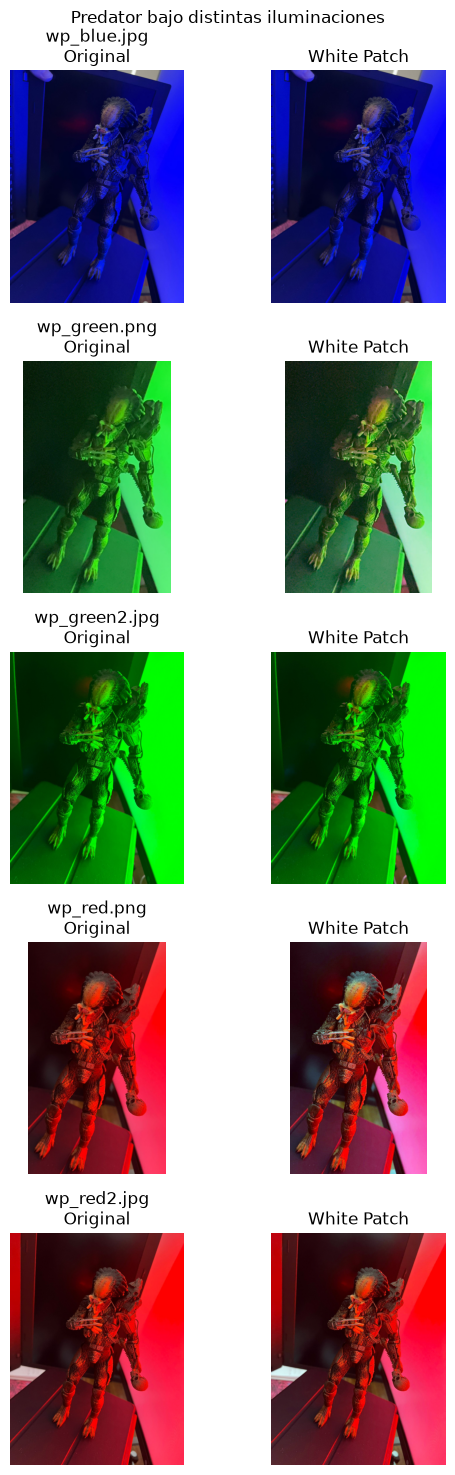

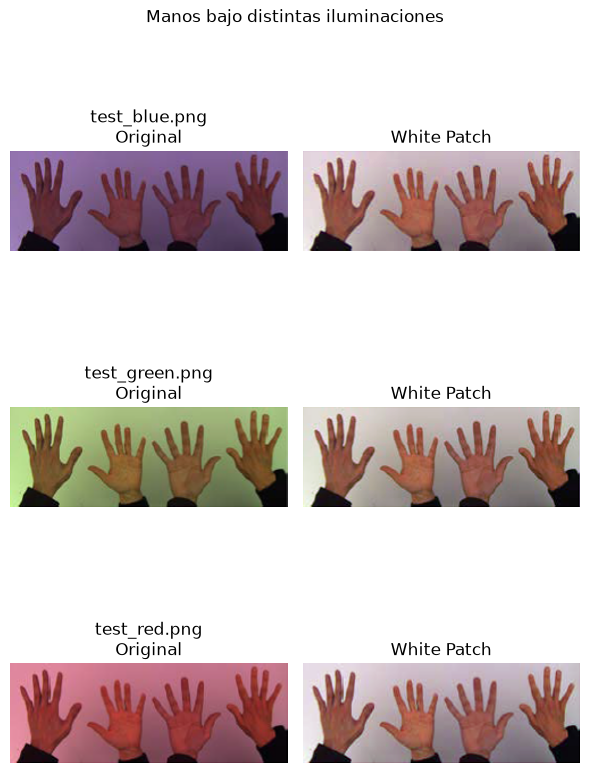

In [3]:
def cargar_imagenes(directorio):
    rutas = sorted(glob.glob(os.path.join(directorio, "*")))
    return {os.path.basename(r): cv.imread(r, cv.IMREAD_COLOR) for r in rutas}


def mostrar_original_vs_corregida(imagenes: dict, titulo: str):
    n = len(imagenes)
    fig, axes = plt.subplots(n, 2, figsize=(6, 3 * n))
    if n == 1:
        axes = axes.reshape(1, 2)

    for fila, (nombre, img_bgr) in enumerate(imagenes.items()):
        corregida_bgr = white_patch(img_bgr)

        axes[fila, 0].imshow(cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB))
        axes[fila, 0].set_title(f"{nombre}\nOriginal")
        axes[fila, 0].axis("off")

        axes[fila, 1].imshow(cv.cvtColor(corregida_bgr, cv.COLOR_BGR2RGB))
        axes[fila, 1].set_title("White Patch")
        axes[fila, 1].axis("off")

    fig.suptitle(titulo)
    fig.tight_layout()
    plt.show()


imagenes_wp = cargar_imagenes(WP_DIR)

predator = {k: v for k, v in imagenes_wp.items() if k.startswith("wp_")}
manos = {k: v for k, v in imagenes_wp.items() if k.startswith("test_")}

mostrar_original_vs_corregida(predator, "Predator bajo distintas iluminaciones")
mostrar_original_vs_corregida(manos, "Manos bajo distintas iluminaciones")

Para entender **por qué** el algoritmo corrige mejor en algunos casos que en otros, es útil mirar los números detrás de la corrección: el máximo por canal que usa como referencia de "blanco", la media de cada canal antes y después, y qué fracción de píxeles termina saturada (en 255) luego de la corrección.

In [4]:
def analizar_white_patch(imagenes: dict):
    print(f"{'archivo':16s} {'max (B,G,R)':>20s} {'media antes (B,G,R)':>26s} {'media después (B,G,R)':>28s} {'% pix. saturados':>18s}")
    print("-" * 112)
    for nombre, img_bgr in imagenes.items():
        img = img_bgr.astype(np.float32)
        max_por_canal = img.reshape(-1, 3).max(axis=0)
        media_antes = img.reshape(-1, 3).mean(axis=0)

        corregida = white_patch(img_bgr)
        media_despues = corregida.reshape(-1, 3).astype(np.float32).mean(axis=0)
        frac_saturados = (corregida == 255).any(axis=2).mean() * 100

        print(f"{nombre:16s} {str(max_por_canal.round(0)):>20s} "
              f"{str(media_antes.round(1)):>26s} {str(media_despues.round(1)):>28s} "
              f"{frac_saturados:>17.1f}%")


analizar_white_patch(imagenes_wp)

archivo                   max (B,G,R)        media antes (B,G,R)        media después (B,G,R)   % pix. saturados
----------------------------------------------------------------------------------------------------------------
test_blue.png        [200. 138. 165.]        [100.7  69.5 103. ]          [127.9 127.9 158.8]               0.0%
test_green.png       [171. 250. 210.]        [ 83.6 131.1 129.4]          [124.1 133.2 156.6]               0.0%
test_red.png         [175. 157. 247.]        [ 91.2  81.1 155.8]          [132.4 131.2 160.4]               0.0%
wp_blue.jpg          [255. 255. 255.]        [121.6  17.1  17.6]          [121.6  17.1  17.6]               0.5%
wp_green.png         [155. 252. 126.]        [ 34.7 102.8  26.2]          [ 56.7 103.5  52.7]               0.0%
wp_green2.jpg        [172. 255. 170.]        [  4.  126.5   4.4]          [  5.6 126.5   6.4]               5.1%
wp_red.png           [122. 134. 255.]        [ 25.2  18.8 122.9]          [ 52.3  35.3 122.9]   

wp_red2.jpg          [203. 201. 255.]        [ 29.7  21.  128.9]          [ 36.8  26.2 128.9]               9.1%


<div style="border:2px solid #8EB15C; background-color:#B1CF86; padding:14px 16px; border-radius:6px; color:#111;">


**Analisis**

1. **`wp_blue.jpg` no cambia en absoluto.** Su máximo por canal ya es `(255, 255, 255)` *antes* de corregir: hay algún píxel (un reflejo puntual, una zona sobreexpuesta) que ya está saturado en los tres canales. El factor de corrección `255/max` da 1 en los tres canales, así que la imagen "corregida" es idéntica a la original y el dominante azul **no se elimina**. Esto expone el punto más débil del algoritmo: confunde un píxel saturado/quemado por sobreexposición con el "blanco" real de la escena, y en ese caso no hay forma de corregir nada.

2. **`wp_red.png`/`wp_red2.jpg` y `wp_green.png`/`wp_green2.jpg` sí se corrigen, pero a costa de saturar entre un 6% y un 9% de los píxeles** (última columna de la tabla). Como el canal dominante (R o G) ya está cerca de 255, la corrección multiplica fuertemente a los canales opuestos lo que satura zonas que antes no lo estaban y puede amplificar el ruido de fondo en canales que partían de señal muy baja (medias de 15-30 sobre 255). Se pierde detalle en las zonas más claras a cambio de recuperar el balance de color.

3. **En las fotos de manos (`test_*`) el dominante se reduce pero no desaparece del todo** (por ejemplo, en `test_red.png` la media del canal R queda ~30 puntos por encima de B/G luego de corregir). Acá no hay ningún objeto realmente blanco o gris neutro en la escena — solo piel y un fondo de color — así que el "máximo por canal" no representa una superficie neutra bajo esa luz, sino simplemente el punto más iluminado de la piel o el fondo. El resultado es una corrección parcial: mejor que el original, pero no un balance de blancos correcto.

**En resumen:** White Patch funciona  mejor cuando existe en la escena un punto realmente neutro (blanco/gris) que no esté saturado por sobreexposición; falla o corrige de forma parcial cuando ese supuesto no se cumple o cuando ya hay saturación previa en algún canal. Una mitigación simple —ya incluida como parámetro `percentile` en la función— es usar un percentil alto pero no absoluto. Hemos realizado pruebas con 95% y las mejoras en wp_blue son sustanciales aunque aumenta la saturación del resto de los ejemplos para predator. En cuanto a los ejemplos de manos, si bien la saturación aumento las diferencias son casi imperceptibles entre 100 y 95.

</div>

## Parte 2 — Histogramas de `img1_tp.png` e `img2_tp.png`

### 2.1 Carga y visualización en escala de grises

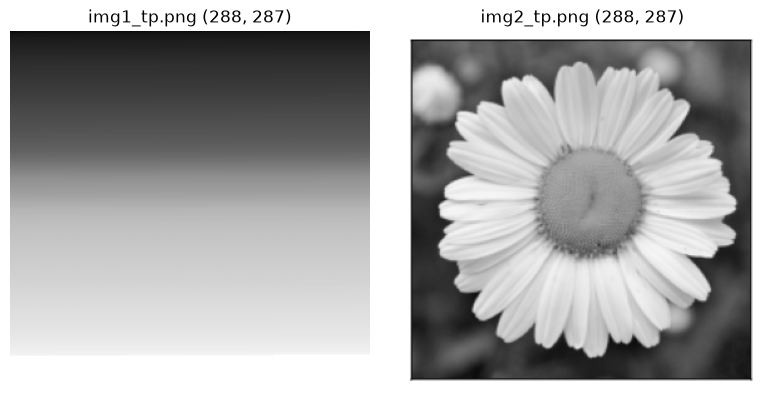

In [5]:
img1 = cv.imread(os.path.join(BASE_DIR, "img1_tp.png"), cv.IMREAD_GRAYSCALE)
img2 = cv.imread(os.path.join(BASE_DIR, "img2_tp.png"), cv.IMREAD_GRAYSCALE)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img1, cmap="gray", vmin=0, vmax=255)
axes[0].set_title(f"img1_tp.png {img1.shape}")
axes[0].axis("off")

axes[1].imshow(img2, cmap="gray", vmin=0, vmax=255)
axes[1].set_title(f"img2_tp.png {img2.shape}")
axes[1].axis("off")

fig.tight_layout()
plt.show()

### 2.2 Elección del número de bins

Antes de fijar un número de bins, veamos cómo cambia el histograma de cada imagen al variar esa cantidad (16, 32 y 256 bins), para elegir uno razonable con criterio en vez de arbitrariamente.

- Con **pocos bins** (ej. 16) el histograma es más robusto/suave pero pierde resolución: intensidades distintas quedan agrupadas en el mismo bin.
- Con **muchos bins** (ej. 256, uno por nivel de intensidad) se tiene la máxima resolución, pero el histograma puede verse "ruidoso" si la imagen no tiene suficientes píxeles para poblar cada nivel de forma estable.

Ambas imágenes son de 287×288 (~82.700 píxeles), un tamaño suficiente para sostener incluso 256 bins sin que se vea demasiado ruidoso. Elegimos **32 bins** como compromiso: da una forma clara de la distribución sin la granularidad excesiva de 256, suficiente para esta comparación.

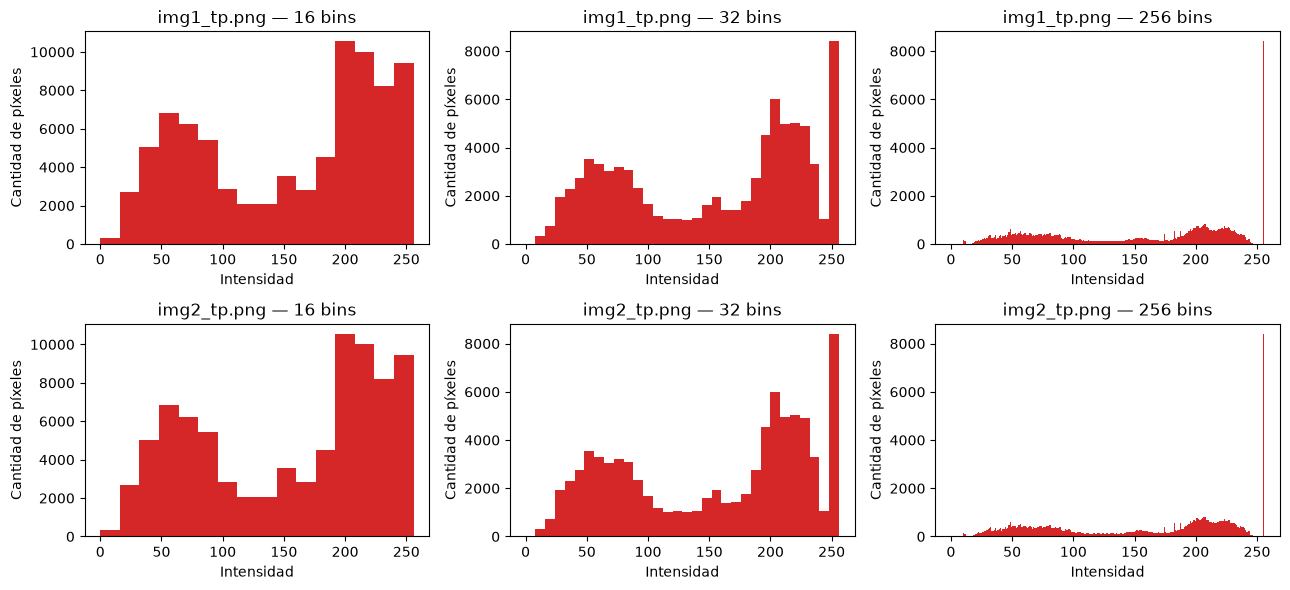

In [6]:
N_BINS = 32

fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for fila, (nombre, img) in enumerate([("img1_tp.png", img1), ("img2_tp.png", img2)]):
    for col, bins in enumerate([16, 32, 256]):
        hist, edges = np.histogram(img.ravel(), bins=bins, range=(0, 256))
        axes[fila, col].bar(edges[:-1], hist, width=np.diff(edges), align="edge", color="tab:red")
        axes[fila, col].set_title(f"{nombre} — {bins} bins")
        axes[fila, col].set_xlabel("Intensidad")
        axes[fila, col].set_ylabel("Cantidad de píxeles")

fig.tight_layout()
plt.show()

### 2.3 Comparación de histogramas (32 bins)

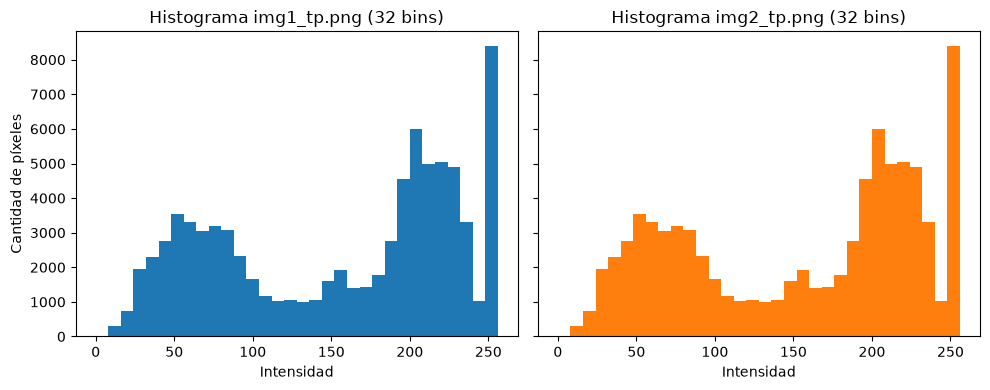

¿Histogramas idénticos bin a bin? True
¿Mismo multiconjunto de valores de píxel (incluso a 256 niveles)? True


In [7]:
hist1, edges = np.histogram(img1.ravel(), bins=N_BINS, range=(0, 256))
hist2, _ = np.histogram(img2.ravel(), bins=N_BINS, range=(0, 256))

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
axes[0].bar(edges[:-1], hist1, width=np.diff(edges), align="edge", color="tab:blue")
axes[0].set_title(f"Histograma img1_tp.png ({N_BINS} bins)")
axes[0].set_xlabel("Intensidad")
axes[0].set_ylabel("Cantidad de píxeles")

axes[1].bar(edges[:-1], hist2, width=np.diff(edges), align="edge", color="tab:orange")
axes[1].set_title(f"Histograma img2_tp.png ({N_BINS} bins)")
axes[1].set_xlabel("Intensidad")

fig.tight_layout()
plt.show()

print("¿Histogramas idénticos bin a bin?", np.array_equal(hist1, hist2))
print("¿Mismo multiconjunto de valores de píxel (incluso a 256 niveles)?",
      np.array_equal(np.sort(img1.ravel()), np.sort(img2.ravel())))

<div style="border:2px solid #8EB15C; background-color:#B1CF86; padding:14px 16px; border-radius:6px; color:#111;">


**Analisis:**

`img1_tp.png` (un degradé vertical) e `img2_tp.png` (la foto de una margarita) son **imágenes completamente distintas**, y sin embargo sus histogramas son **exactamente iguales**, bin a bin, sea con 16, 32 o 256 bins.

Esto ilustra de forma muy directa que **el histograma global descarta toda la información espacial de la imagen**. Solo le importa "cuántos píxeles hay de cada intensidad", no en qué posición están ni cómo se relacionan con sus vecinos (bordes, texturas, formas).

**¿Sirve el histograma como *feature* para clasificación/detección?**

- Para **clasificación**, un histograma global puede aportar algo (captura estadísticas generales de iluminación/contraste de la imagen) pero  **no alcanza por sí solo**: dos imágenes de clases completamente distintas pueden tener histogramas indistinguibles. Como feature único sería débil; como *feature* complementario (concatenado a otras características) puede sumar algo de información global barata de calcular.
- Para **detección**, el histograma global es aún menos útil, porque detección requiere **localizar** el objeto dentro de la imagen, y un histograma global no contiene ninguna información de posición.
</div>